In [10]:
#import relevant libraries
import os

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import dabest

import NLCLIMB_asyn
import NLMATH_asyn

#NOTE: SUPPRESSES WARNINGS!

import warnings

warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)

In [11]:
metricframe_cache = {}

def metricframe(genotype):
    if genotype in metricframe_cache:
        return metricframe_cache[genotype].copy()

    df = pd.read_csv(openPath + genotype + ".csv")
    df = df.drop(df.columns[[0]], axis = 1)   #the compiled CSVs carry an index column
    df = NLCLIMB_asyn.generation(df, genotype)

    cy = NLMATH_asyn.calcgraph(df, "Y.*")
    cv = NLMATH_asyn.calcgraph(df, "Velocity.*")
    cb = NLMATH_asyn.calcgraph(NLMATH_asyn.boutspeed(df), "BSpeed.*")
    si = NLMATH_asyn.straightnessindexmeter(df, genotype)

    out = pd.DataFrame()
    for n in phase:
        h = cy[cy.ExperimentState == n].iloc[:, 2:].mean(axis=0)
        v = cv[cv.ExperimentState == n].iloc[:, 2:].mean(axis=0)
        b = cb[cb.ExperimentState == n].iloc[:, 2:].mean(axis=0)
        s = si[si.ExperimentState == n]["averagestraightnessindex"]

        t = pd.DataFrame({"Height": h.values, "Speed": v.values,
                          "BSpeed": b.values, "SI": s.values})
        t["fly"] = [genotype + "_" + c.rsplit("_", 1)[-1] for c in h.index]
        t["Phase"] = n
        out = pd.concat([out, t])

    out = out.reset_index(drop=True)
    metricframe_cache[genotype] = out

    return out.copy()

In [12]:
#initial file processing

laptop = "C:\\Users\\Nicole Lee\\"
homecomp = "C:\\Users\\user\\"
labcomp = "C:\\Users\\User\\"

path2 = "NUS Dropbox\\acclab\\Nicole M Lee\\"
openPath = homecomp + path2 + "PD\\Data Compilation\\"
savefiglocation = openPath + "images\\"

expt = "elav x 51376_D30"
isExist = os.path.exists(savefiglocation)
if not isExist:
    os.makedirs(savefiglocation)

phase = ["First phase", "Second phase", "Third phase"]
metrics = ["Height", "Speed", "BSpeed", "SI"]
rawlabels = {"Height": "Height climbed (mm)", "Speed": "Overall speed (mm/s)",
             "BSpeed": "Bout speed (mm/s)", "SI": "Straightness index"}
phaselabels = {"First phase": "1st", "Second phase": "2nd", "Third phase": "3rd"}

#the experimental is always light blue, the driver control black, the responder control brown
lightblue = "#4DA6FF"
brown = "#8B4513"

listofgenotypes = sorted(f[:-4] for f in os.listdir(openPath) if f.endswith(".csv"))

print(len(listofgenotypes), "genotypes")


44 genotypes


In [13]:
#PLOT 1 - the three phases against each other, paired, first phase as the baseline.

cross, age = expt.rsplit("_", 1)
driver, responder = cross.split(" x ", 1)

wts = []
for side, parent in zip(["driver", "responder"], [driver, responder]):
    control = "w1118 x " + parent + "_" + age
    if control in listofgenotypes:
        wts.append(control)
    else:
        print("the " + side + " control " + control + " does not exist, plotting without it")

if len(wts) == 0:
    raise Exception("neither parental control of " + expt + " exists, nothing to plot against")

#the controls go in first so they come first in the legend. The crosses are written
#with " > " rather than " x " on the figure, which is the more accurate annotation.
data1 = pd.DataFrame()
sources1 = {}

for control, colour in zip(wts, ["#000000", brown]):
    label = "Control: " + control.replace(" x ", " > ")
    data1 = pd.concat([data1, metricframe(control).assign(Group = "Control", Source = label)])
    sources1[label] = colour

exptlabel = "Expt: " + expt.replace(" x ", " > ")
data1 = pd.concat([data1, metricframe(expt).assign(Group = "Expt", Source = exptlabel)])
sources1[exptlabel] = lightblue

data1 = data1.reset_index(drop=True)
data1["genre"] = data1["Phase"].map(phaselabels) + "_" + data1["Group"]

idx1 = (tuple(phaselabels[n] + "_Control" for n in phase),
        tuple(phaselabels[n] + "_Expt" for n in phase))

print(data1.groupby(["Group", "Source"]).size().to_string())

the responder control w1118 x 51376_D30 does not exist, plotting without it
Group    Source                   
Control  Control: w1118 > elav_D30    63
Expt     Expt: elav > 51376_D30       81


C:\Users\user\NUS Dropbox\acclab\Nicole M Lee\PD\Data Compilation\images\Dabest_Height_elav x 51376_D30.svg
C:\Users\user\NUS Dropbox\acclab\Nicole M Lee\PD\Data Compilation\images\Dabest_Speed_elav x 51376_D30.svg
C:\Users\user\NUS Dropbox\acclab\Nicole M Lee\PD\Data Compilation\images\Dabest_BSpeed_elav x 51376_D30.svg
C:\Users\user\NUS Dropbox\acclab\Nicole M Lee\PD\Data Compilation\images\Dabest_SI_elav x 51376_D30.svg


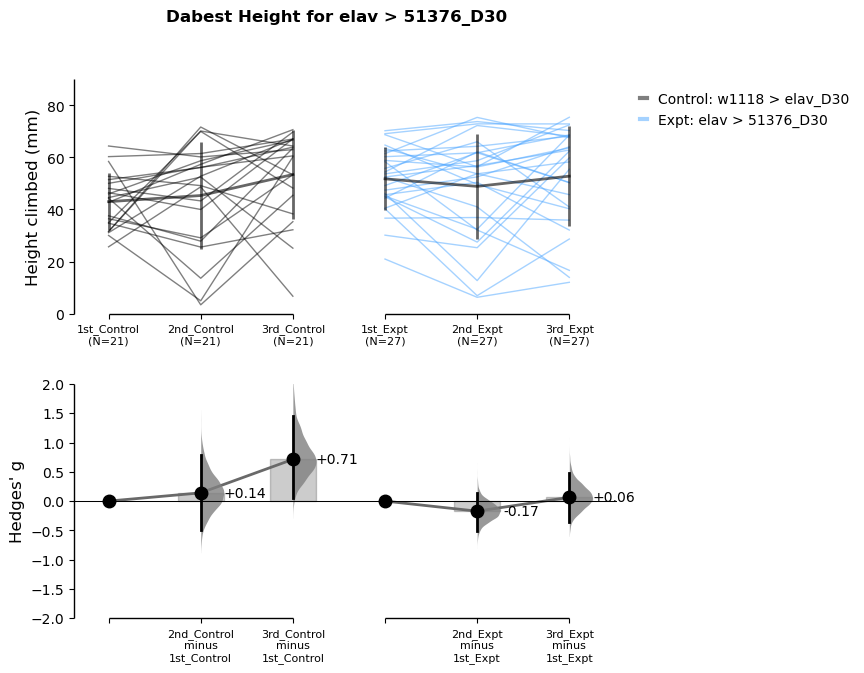

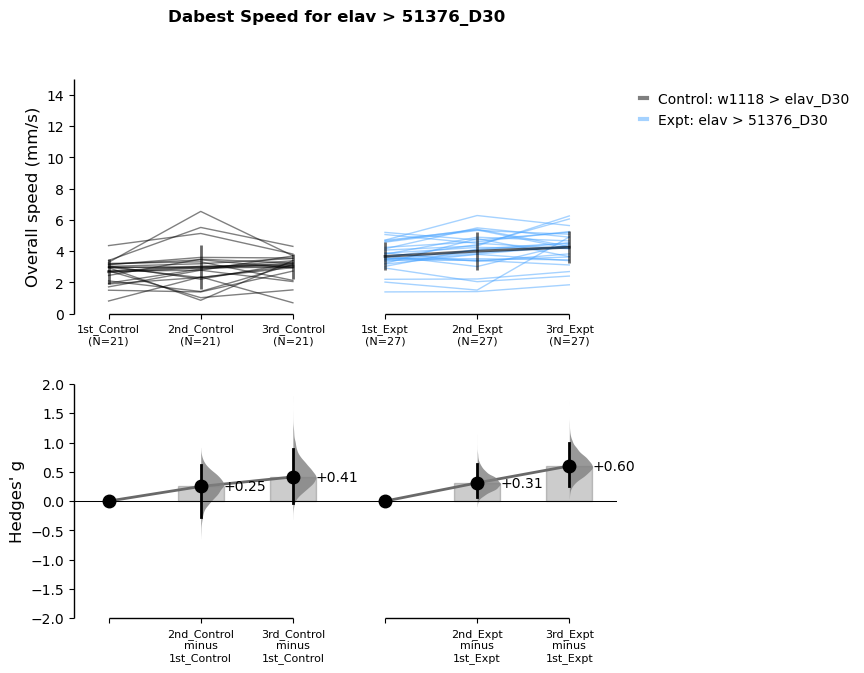

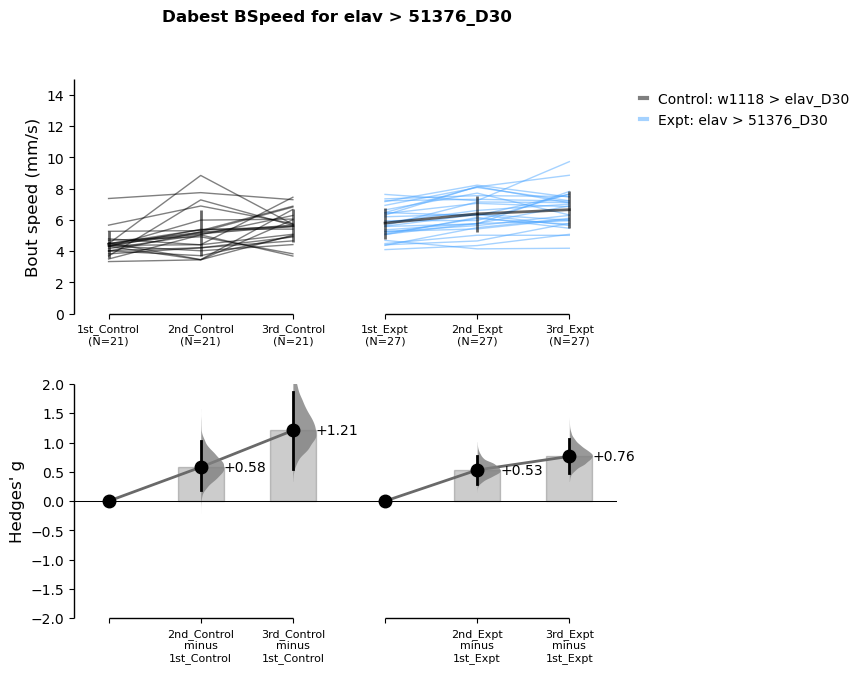

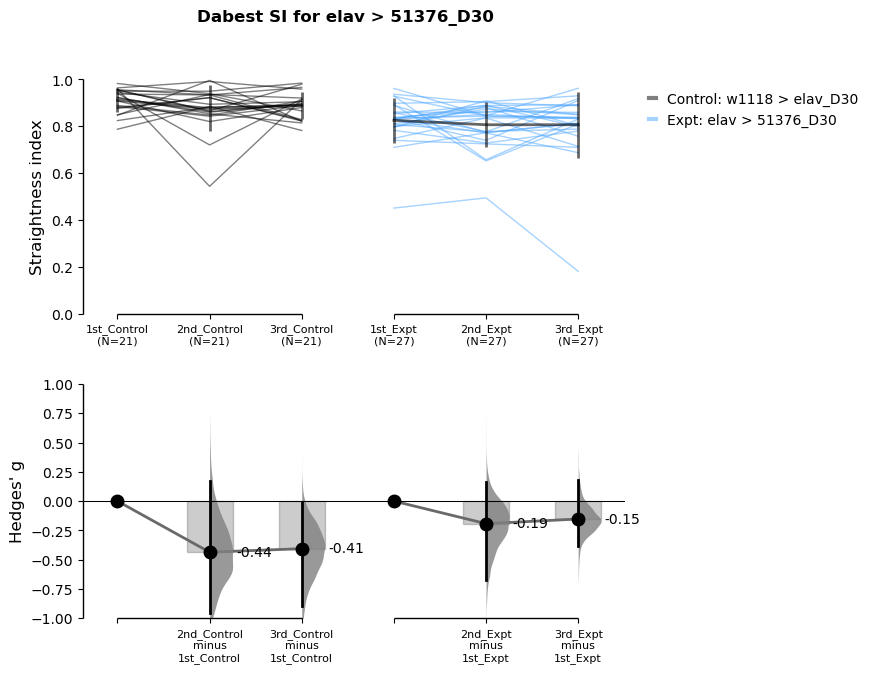

In [14]:
#PLOT 1 figures, one per metric

mpl.rcParams['svg.fonttype'] = 'none'

#axis ranges, per metric. Edit these.
rawylims = {"Height": (0, 90), "Speed": (0, 15), "BSpeed": (0, 15), "SI": (0, 1)}
contrastylims = {"Height": (-2, 2), "Speed": (-2, 2), "BSpeed": (-2, 2), "SI": (-1, 1)}

for m in metrics:
    db = dabest.load(data = data1, idx = idx1, x = "genre", y = m,
                     paired = "baseline", id_col = "fly")

    #dabest crashes on a paired plot given both color_col and custom_palette, so the
    #colours go in through seaborn, ordered the way dabest walks the colour column
    order = list(pd.unique(db._plot_data["Source"]))
    sns.set_palette([sources1[o] for o in order])

    figdb = db.hedges_g.plot(color_col = "Source",
                              raw_label = rawlabels[m],
                              contrast_label = "Hedges' g",
                              raw_desat = 1, contrast_desat = 1, 
                              fig_size = (7, 7),
                              raw_ylim = rawylims[m], contrast_ylim = contrastylims[m],
                              fontsize_rawxlabel = 8, fontsize_contrastxlabel = 8)

    figdb.suptitle("Dabest " + m + " for " + expt.replace(" x ", " > "), fontweight = 'bold', fontsize = 12)
    #figdb.savefig(savefiglocation + "Dabest_" + m + "_" + expt + ".svg", bbox_inches='tight')

    print(savefiglocation + "Dabest_" + m + "_" + expt + ".svg")

In [15]:
#PLOT 2 - one phase, control against experimental, at each age. Unpaired: the ages are
#different flies, so there is nothing to join up. Controls are piled as in plot 1.

cross = "elav x 51376"
chosen = "First phase"

driver, responder = cross.split(" x ", 1)
ages = [a for a in ["D10", "D20", "D30"] if cross + "_" + a in listofgenotypes]
print(cross, "has", ages)

#the controls go in first so they come first in the legend. The crosses are written
#with " > " rather than " x " on the figure, which is the more accurate annotation.
data2 = pd.DataFrame()
sources2 = {}

exptlabel = "Expt: " + cross.replace(" x ", " > ")

for a in ages:
    for side, parent in zip(["driver", "responder"], [driver, responder]):
        control = "w1118 x " + parent + "_" + a
        if control in listofgenotypes:
            label = "Control: w1118 > " + parent
            data2 = pd.concat([data2, metricframe(control).assign(Group = "Control " + a,
                                                                  Source = label)])
            sources2[label] = "#000000" if side == "driver" else brown
        else:
            print("the " + side + " control " + control + " does not exist, plotting without it")

    data2 = pd.concat([data2, metricframe(cross + "_" + a).assign(Group = "Expt " + a,
                                                                  Source = exptlabel)])

sources2[exptlabel] = lightblue

data2 = data2.reset_index(drop=True)
data2 = data2[data2.Phase == chosen].reset_index(drop=True)

idx2 = tuple(("Control " + a, "Expt " + a) for a in ages)

print(data2.groupby(["Group", "Source"]).size().to_string())

elav x 51376 has ['D10', 'D20', 'D30']
the responder control w1118 x 51376_D10 does not exist, plotting without it
the responder control w1118 x 51376_D20 does not exist, plotting without it
the responder control w1118 x 51376_D30 does not exist, plotting without it
Group        Source               
Control D10  Control: w1118 > elav    88
Control D20  Control: w1118 > elav    46
Control D30  Control: w1118 > elav    21
Expt D10     Expt: elav > 51376       78
Expt D20     Expt: elav > 51376       34
Expt D30     Expt: elav > 51376       27


C:\Users\user\NUS Dropbox\acclab\Nicole M Lee\PD\Data Compilation\images\Dabest_Height_elav x 51376_First phase.svg
C:\Users\user\NUS Dropbox\acclab\Nicole M Lee\PD\Data Compilation\images\Dabest_Speed_elav x 51376_First phase.svg
C:\Users\user\NUS Dropbox\acclab\Nicole M Lee\PD\Data Compilation\images\Dabest_BSpeed_elav x 51376_First phase.svg
C:\Users\user\NUS Dropbox\acclab\Nicole M Lee\PD\Data Compilation\images\Dabest_SI_elav x 51376_First phase.svg


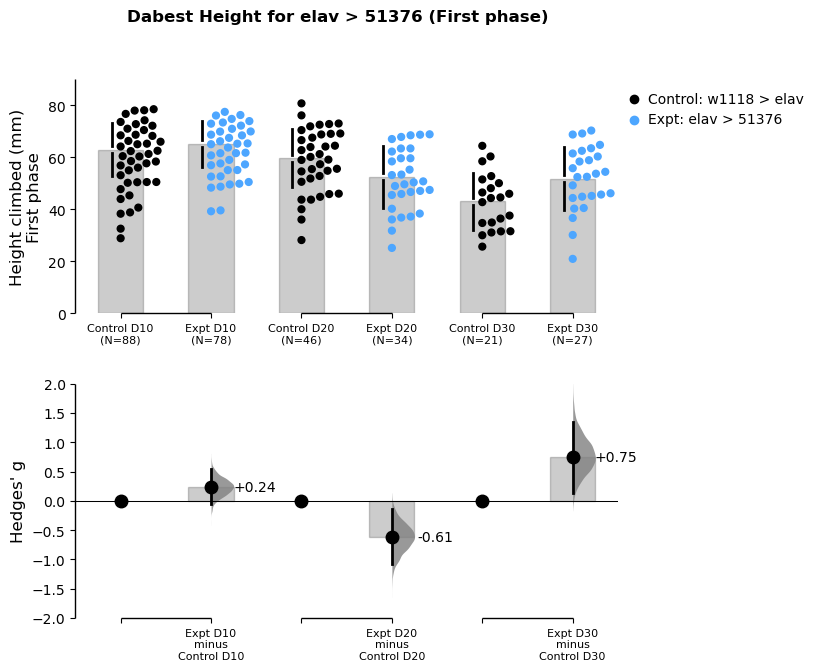

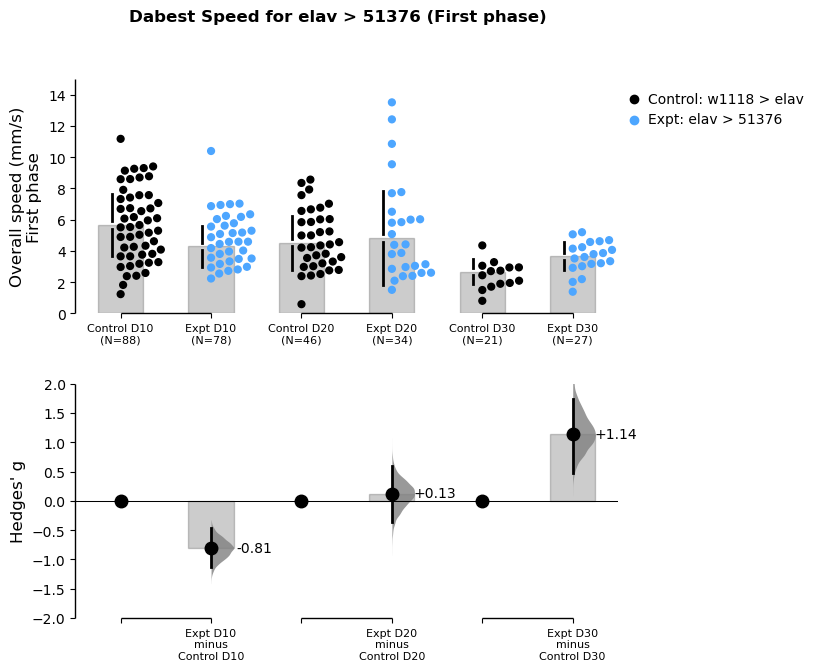

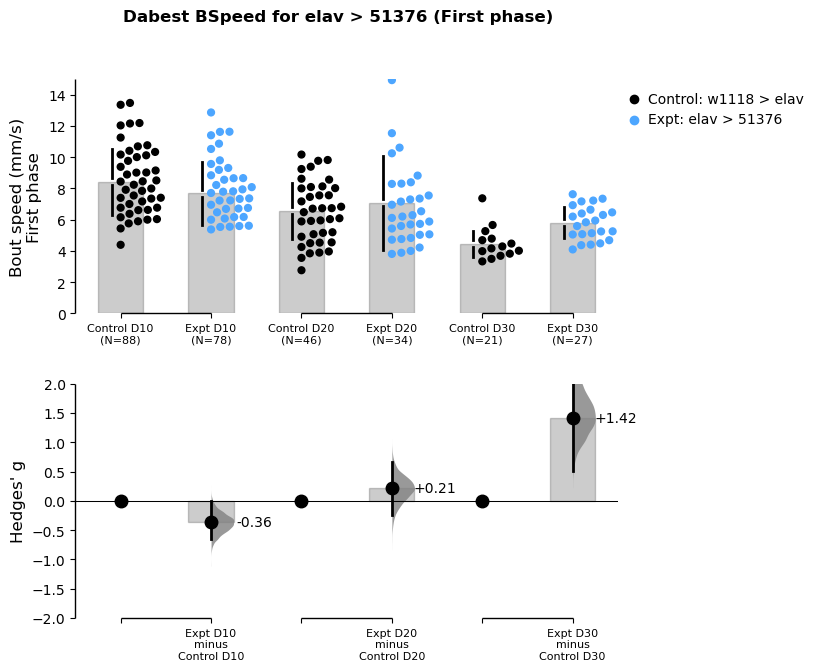

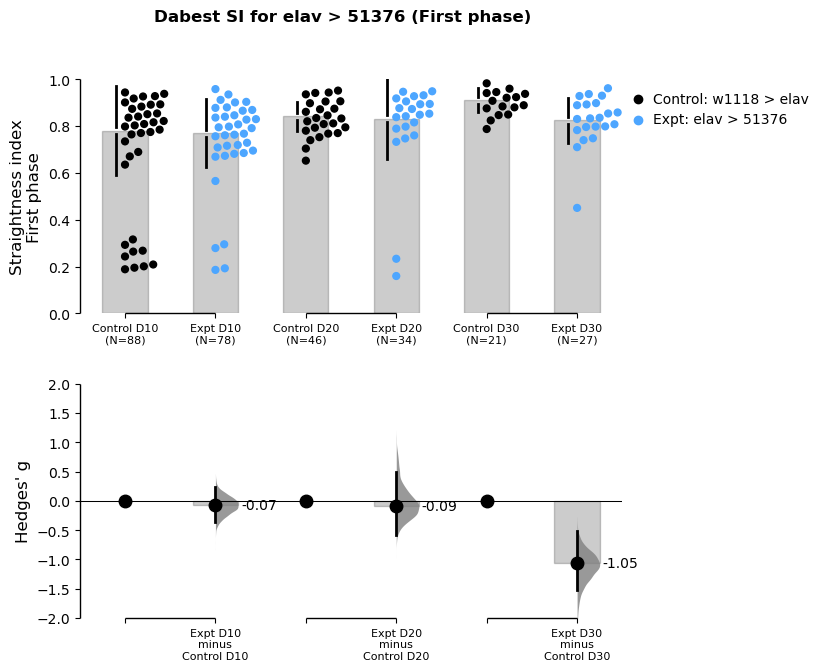

In [16]:
#PLOT 2 figures, one per metric

mpl.rcParams['svg.fonttype'] = 'none'

#axis ranges, per metric. 
rawylims = {"Height": (0, 90), "Speed": (0, 15), "BSpeed": (0, 15), "SI": (0, 1)}
contrastylims = {"Height": (-2, 2), "Speed": (-2, 2), "BSpeed": (-2, 2), "SI": (-2, 2)}

for m in metrics:
    db = dabest.load(data = data2, idx = idx2, x = "Group", y = m)

    order = list(pd.unique(db._plot_data["Source"]))
    sns.set_palette([sources2[o] for o in order])

    figdb = db.hedges_g.plot(color_col = "Source",
                              raw_label = rawlabels[m] + "\n" + chosen,
                              contrast_label = "Hedges' g",
                              raw_desat = 1, contrast_desat = 1,
                              fig_size = (7, 7),
                              raw_ylim = rawylims[m], contrast_ylim = contrastylims[m],
                              fontsize_rawxlabel = 8, fontsize_contrastxlabel = 8)

    figdb.suptitle("Dabest " + m + " for " + cross.replace(" x ", " > ") + " (" + chosen + ")",
                   fontweight = 'bold', fontsize = 12)
    #figdb.savefig(savefiglocation + "Dabest_" + m + "_" + cross + "_" + chosen + ".svg", bbox_inches='tight')

    print(savefiglocation + "Dabest_" + m + "_" + cross + "_" + chosen + ".svg")